#Requirements

In [1]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import json
from skimage.exposure import match_histograms

# Dataset Pre-processing

In [ ]:
!gdown "19FAA4_z7xzdqqtwnkLRL2oI4PuMWPYBZ&confirm=t" -q
!gdown "1ixS6ump2gFwwChlg4vrGyVa_9t0csLKd&confirm=t" -q
!unzip /content/Dataset.zip -d Dataset 
!unzip /content/Patterns.zip -d Patterns 

In [2]:
img_name = "/content/Dataset/1644369207.922902.jpg"
json_name = img_name[:-3] + "json"

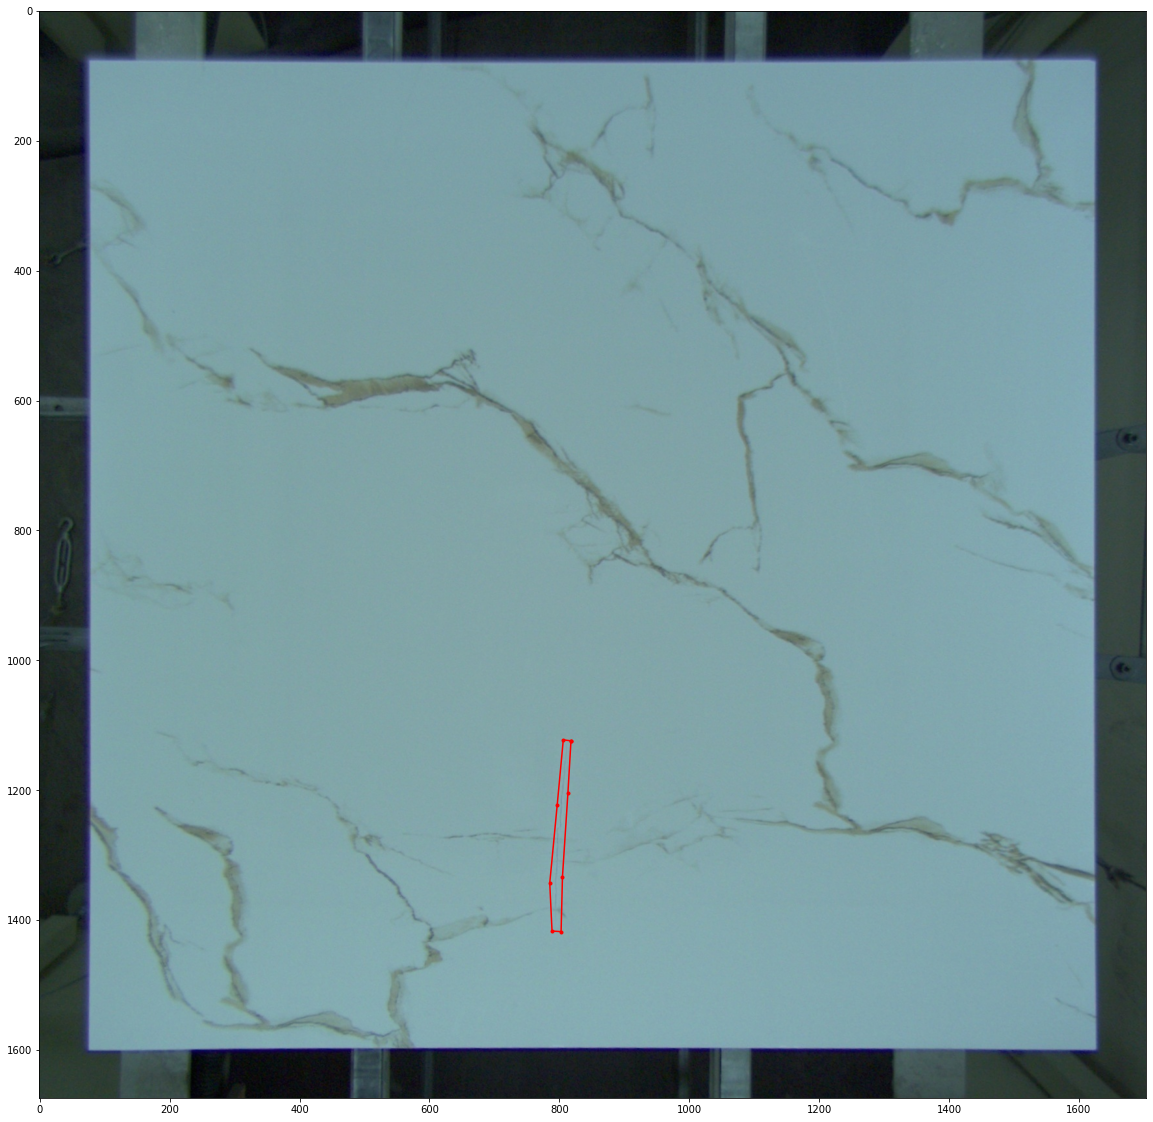

In [3]:
img = cv.imread(img_name).astype('uint8')

f = open(json_name, encoding="utf8")
data = json.load(f)
f.close()

plt.figure(figsize=(20, 20))
plt.imshow(img[..., ::-1])

for shape in data["shapes"]:
  points = np.array(shape['points'])
  ind = list(np.arange(points.shape[0])) + [0]
  plt.plot(points[ind, 0], points[ind, 1], 'r.-')
  # plt.plot(points[-1:-3:-1, 0], points[-1:-3:-1, 1], 'r')

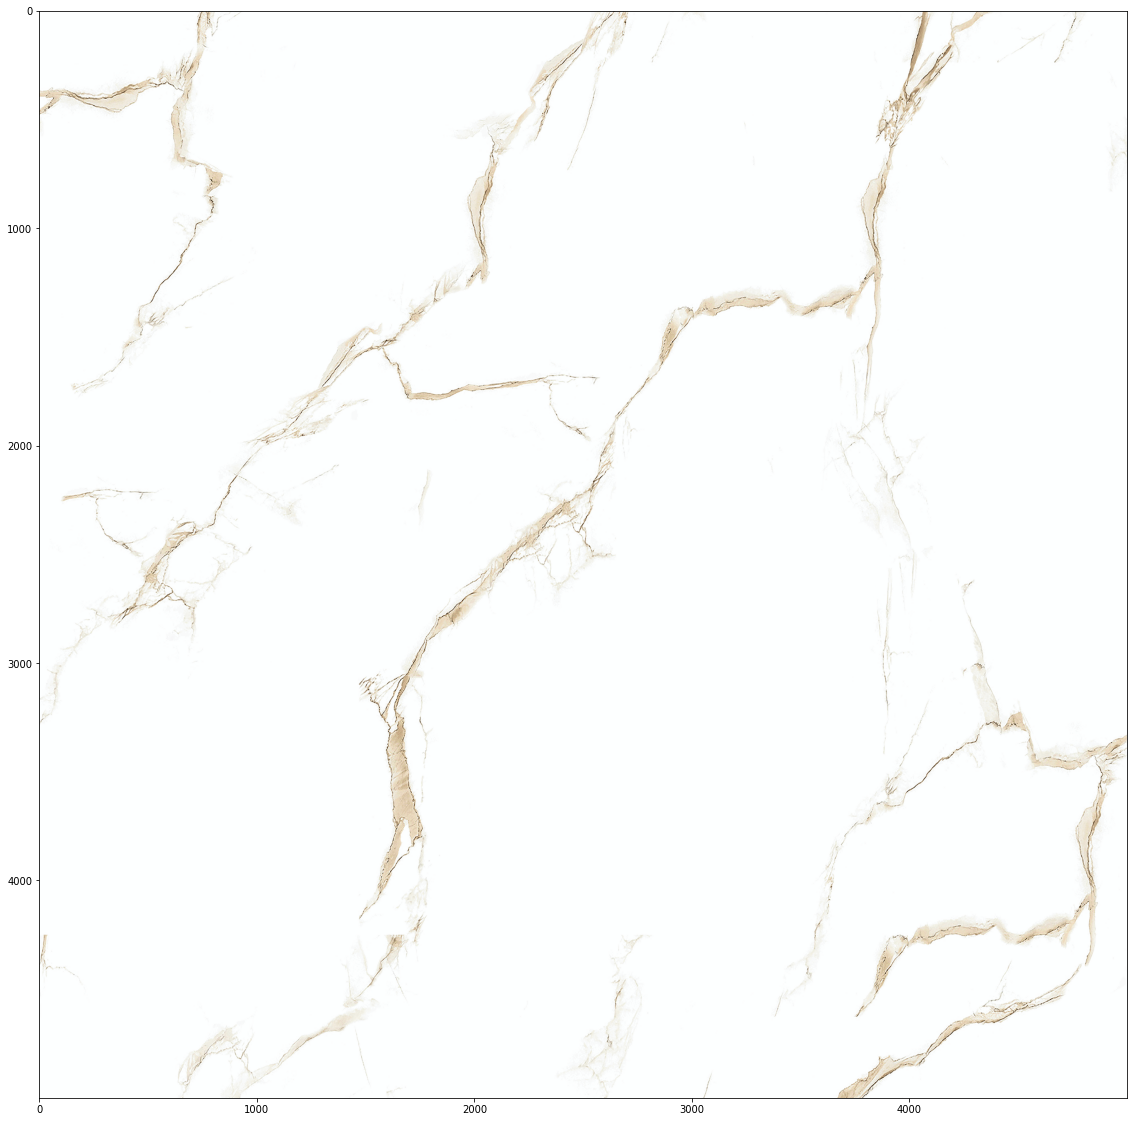

In [4]:
pattern = cv.imread('/content/Patterns/' + data['pattern'])

plt.figure(figsize=(20, 20))
plt.imshow(pattern[..., ::-1])

In [5]:
def apply_threshold(img_gray):
  ret, thresh = cv.threshold(img_gray, 250.00, 255.00, int(cv.THRESH_OTSU))
  plt.imshow(cv.cvtColor(thresh, cv.COLOR_BGR2RGB))
  plt.title('After applying OTSU threshold')
  plt.show()
  return thresh

In [6]:
def morphology(img_binary, kernel = np.ones((35, 35), np.uint8)):
  opening = cv.morphologyEx(img_binary, cv.MORPH_OPEN, kernel)
  closing = cv.morphologyEx(opening, cv.MORPH_CLOSE, kernel)
  plt.imshow(cv.cvtColor(closing, cv.COLOR_BGR2RGB))
  plt.title('After applying morphology transformation')
  plt.show()
  return closing

In [7]:
def crop_image(img, img_binary):
  mask = img_binary==255
  img_cropped = img[np.ix_(mask.any(1), mask.any(0))]
  img_cropped = img_cropped[5:-5, 5:-5]
  plt.imshow(cv.cvtColor(img_cropped, cv.COLOR_BGR2RGB))
  plt.title('After cropping_image')
  plt.show()
  return img_cropped

In [8]:
def histogram_matching(img_cropped, pattern):
  m = match_histograms(img_cropped, pattern, multichannel=True)
  plt.imshow(cv.cvtColor(m, cv.COLOR_BGR2RGB))
  plt.title('After histogram matching')
  plt.show()
  return m

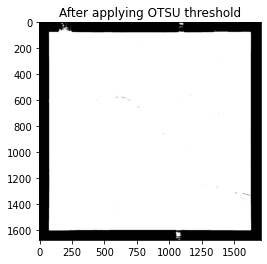

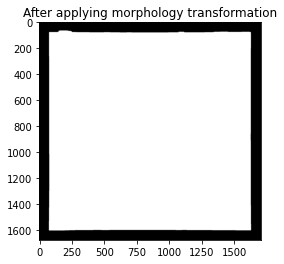

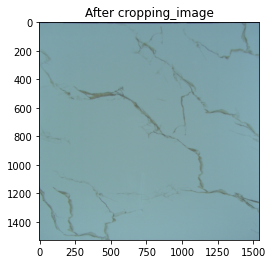

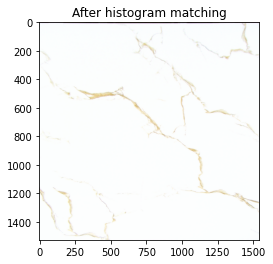

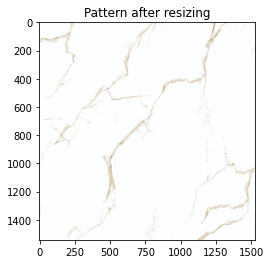

In [10]:
def pre_processing(img):
  img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
  img_binary = apply_threshold(img_gray)
  img_binary = morphology(img_binary)
  img_cropped = crop_image(img, img_binary)
  img_matched = histogram_matching(img_cropped, pattern)
  pattern_resized = cv.resize(pattern, (img_matched.shape[0], img_matched.shape[1]))
  plt.imshow(cv.cvtColor(pattern_resized, cv.COLOR_BGR2RGB))
  plt.title('Pattern after resizing')
  plt.show()

pre_processing(img)

# Model